# Spatial views and recording

This example builds one real multicompartment population with sodium, potassium, and leak channels. It demonstrates spatial selection, mechanism views, layout-free recording, a registered NetStim population, and continued Network runs.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
import matplotlib.pyplot as plt
import numpy as np
import braincell
import brainunit as u
from braincell.filter import BranchSlice, at

## 1. Cell population and density mechanisms

The morphology has one soma and two dendrites. `CVPerBranchList((1, 4, 4))` produces nine CVs per cell. Density mechanisms are shared declarations with SoA runtime arrays; explicit names are the stable logical owners used by views and recordings.

In [2]:
soma = braincell.Branch.from_lengths(
    lengths=[20.0] * u.um, radii=[10.0, 10.0] * u.um, type="soma"
)
dend_a = braincell.Branch.from_lengths(
    lengths=[120.0] * u.um, radii=[2.0, 1.0] * u.um, type="dendrite"
)
dend_b = braincell.Branch.from_lengths(
    lengths=[160.0] * u.um, radii=[2.5, 0.8] * u.um, type="dendrite"
)
morpho = braincell.Morphology.from_root(soma, name="soma")
morpho.soma.dend_a = dend_a
morpho.soma.dend_b = dend_b

cell = braincell.Cell(
    morpho, cv_policy=braincell.CVPerBranchList((1, 4, 4)),
    pop_size=(4,), solver="staggered", V_init=-65.0 * u.mV, name="post"
)
whole = BranchSlice([0, 1, 2], 0.0, 1.0)
cell.paint(whole, braincell.mech.Ion("SodiumFixed", name="na_pool", E=50.0 * u.mV))
cell.paint(whole, braincell.mech.Ion("PotassiumFixed", name="k_pool", E=-77.0 * u.mV))
cell.paint(whole, braincell.mech.Channel("Na_HH1952", name="na", g_max=120.0 * u.mS / u.cm**2))
cell.paint(whole, braincell.mech.Channel("K_HH1952", name="k", g_max=36.0 * u.mS / u.cm**2))
cell.paint(whole, braincell.mech.Channel("IL", name="leak", g_max=0.3 * u.mS / u.cm**2, E=-54.387 * u.mV))
print(cell[[0, 2]].dendrite.cv[1:])
print(cell.soma.channels)

CellView(name='post', population_indices=(0, 2), cv_ids=(2, 3, 4, 5, 6, 7, 8))
ChannelView(rows=12, Na_HH1952(na: 4), K_HH1952(k: 4), IL(leak: 4))


## 2. Independent synapses and views

Population members 0-1 receive `fast` ExpSyn instances on dendrite A; members 2-3 receive `slow` Exp2Syn instances on dendrite B. The view aggregates by type and name while numeric SynapseView indexing preserves stable logical instance IDs.

In [3]:
cell[0:2].place(
    at("dend_a", 0.35),
    braincell.mech.SynapseSpec("ExpSyn", name="fast", tau=[1.5, 2.0] * u.ms),
)
print(cell.synapses)
print("fast IDs:", cell.synapses["fast"].id)
print("The slow group will be created by Network.connect().")

SynapseView(target=CellView(name='post', cells=[0, 1]), size=2, synapse_type=ExpSyn, names={'fast': 2}, parameters=('e', 'tau'))
fast IDs: [0 5]
The slow group will be created by Network.connect().


## 3. Recording selection matrix

| Request | Scope | Observable | Output rows |
| --- | --- | --- | --- |
| Voltage | cells 0-1, dendrites, CV 1 onward | `observe.state("v")` | one row per selected `(cell, CV)` |
| Sodium gate | soma | channel `na`, state `p` | one row per `(cell, owner, CV)` |
| Sodium current | soma | channel `na`, current | summed per `(cell, CV)` |
| Synapse conductance | all cells | synapse types | one row per logical synapse |

Recording declarations do not call `place()` and do not allocate point mechanisms.

In [4]:
cell[0:2].dendrite.cv[1:].record("dend_v", braincell.observe.state("v"), period=0.1 * u.ms)
cell.soma.record("na_p", braincell.observe.channel(name="na").state("p"), period=0.1 * u.ms)
cell.soma.record("na_current", braincell.observe.channel(name="na").current(), period=0.1 * u.ms)
cell.record("fast_g", braincell.observe.synapse(name="fast").state("g"), period=0.1 * u.ms)
cell.record("slow_g", braincell.observe.synapse(name="slow").state("g"), period=0.1 * u.ms)
print("recordings:", tuple(cell.recordings))
print("point placements remain synapses only:", len(cell.point_placements))

recordings: ('dend_v', 'na_p', 'na_current', 'fast_g', 'slow_g')
point placements remain synapses only: 2


## 4. Registered event source and direct routing

A NetStim is a Population with one canonical `spike` port. Passing that Population to `connect()` is shorthand for its only port. Here explicit source slices align with the two heterogeneous synapse groups.

In [5]:
stim = braincell.NetStim(
    size=4, start=[0.5, 0.7, 1.0, 1.2] * u.ms,
    number=3, interval=1.5 * u.ms, noise=0.0,
)
net = braincell.Network("recording_demo", seed=7)
stim_pop = net.add_population("stim", stim, source_class="artificial")
post_pop = net.add_population("post", cell, layer="demo")
net.connect("stim_fast", source=stim_pop.sources["spike"][0:2], synapse=post_pop.synapses["fast"], weight=0.08 * u.uS)
net.connect(
    "stim_slow",
    source=stim_pop.sources["spike"][2:4],
    target=cell[2:4], locations=at("dend_b", 0.70),
    synapse=braincell.mech.SynapseSpec("Exp2Syn", name="slow", tau1=0.5 * u.ms, tau2=5.0 * u.ms),
    weight=0.12 * u.uS,
)
print(stim_pop)
print(post_pop)
print(net)
print(net.connections["post", "stim_slow"].synapse)

Population(name='stim', kind='netstim', size=4, model=NetStim, fields=('source_class',), initialized=False)
Population(name='post', kind='cell', size=4, model=Cell, fields=('layer',), initialized=False)
Network(name='recording_demo', populations=2, connections=2, rows=4)
  populations:
    stim: size=4, kind=netstim, model=NetStim, initialized=False
    post: size=4, kind=cell, model=Cell, initialized=False
  connections:
    post: connections=2, rows=4
      stim_fast: NetStim(stim) -> ExpSyn(fast), rows=2
      stim_slow: NetStim(stim) -> Exp2Syn(slow), rows=2
SynapseView(target=CellView(name='post', cells=[2, 3]), size=2, synapse_type=Exp2Syn, names={'slow': 2}, parameters=('e', 'tau1', 'tau2'))


## 5. Continued run and immutable results

The two segments share one global recording schedule. Concatenation checks continuity, `dt`, and schemas. Scheduled source events are returned sparsely instead of as a padded time-by-source matrix.

In [6]:
first = net.run(dt=0.025 * u.ms, duration=25 * u.ms, spike_recording="population")
second = net.run(dt=0.025 * u.ms, duration=25 * u.ms, spike_recording="population")
result = braincell.NetworkResult.concat((first, second))

for name, block in result.samples["post"].items():
    print(f"{name:12s} samples={block.values.shape[0]:3d} rows={block.schema.size:2d} unit={block.schema.rows[0].unit}")
events = result.events["stim"]["spike"]
print("event rows (time ms, source, count):")
print(list(zip(events.time.to_decimal(u.ms).tolist(), events.source_id.tolist(), events.count.tolist())))

net.reset_state()
continuous = net.run(dt=0.025 * u.ms, duration=50 * u.ms, spike_recording="population")
for name, block in result.samples["post"].items():
    unit = block.schema.rows[0].unit
    split_values = block.values if unit is None else block.values.to_decimal(unit)
    full_values = continuous.samples["post"][name].values
    full_values = full_values if unit is None else full_values.to_decimal(unit)
    np.testing.assert_allclose(split_values, full_values, rtol=1e-6, atol=1e-7)
print("split 25+25 ms matches continuous 50 ms")

dend_v       samples=500 rows=14 unit=mV
na_p         samples=500 rows= 4 unit=None
na_current   samples=500 rows= 4 unit=10.0^-2 * A / m^2
fast_g       samples=500 rows= 2 unit=uS
slow_g       samples=500 rows= 2 unit=uS
event rows (time ms, source, count):
[(0.5, 0, 1), (0.699999988079071, 1, 1), (1.0, 2, 1), (1.2000000476837158, 3, 1), (2.0, 0, 1), (2.199999988079071, 1, 1), (2.5, 2, 1), (2.700000047683716, 3, 1), (3.5, 0, 1), (3.699999988079071, 1, 1), (4.0, 2, 1), (4.200000047683716, 3, 1)]
split 25+25 ms matches continuous 50 ms


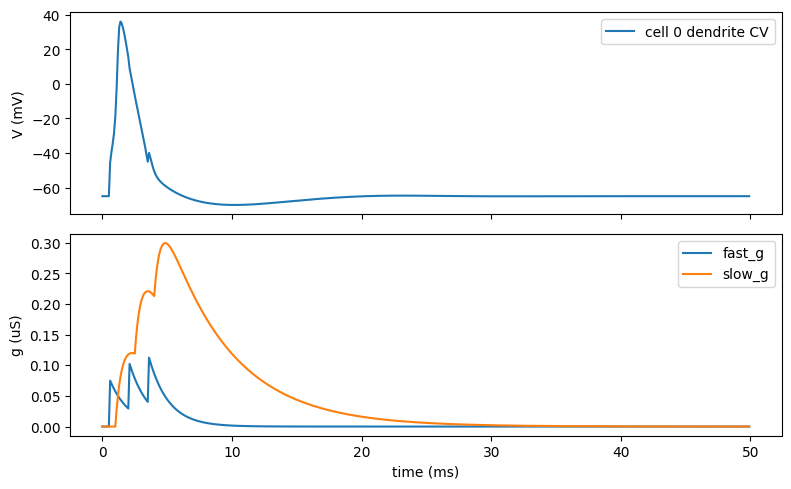

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
v = result.samples["post"]["dend_v"]
axes[0].plot(v.time.to_decimal(u.ms), v.values[:, 0].to_decimal(u.mV), label="cell 0 dendrite CV")
axes[0].set_ylabel("V (mV)")
axes[0].legend()
for name in ("fast_g", "slow_g"):
    block = result.samples["post"][name]
    axes[1].plot(block.time.to_decimal(u.ms), block.values[:, 0].to_decimal(u.uS), label=name)
axes[1].set(xlabel="time (ms)", ylabel="g (uS)")
axes[1].legend()
fig.tight_layout()